# GP Volatility: Predicted vs Actual (Last Month)

This notebook loads the latest GP artifacts from `vol_gp/artifacts`, rebuilds the dataset, and plots predicted vs actual 5-day forward realized volatility for the most recent month of data.


In [3]:
import json
import sys
from pathlib import Path

import gpytorch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Resolve paths
root = Path.cwd()
if root.name != "vol_gp" and (root / "vol_gp").exists():
    base_dir = root / "vol_gp"
else:
    base_dir = root

repo_root = base_dir.parent if base_dir.name == "vol_gp" else base_dir

if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))
if str(base_dir) not in sys.path:
    sys.path.append(str(base_dir))

from common import parse_window, walk_forward_splits
import train

artifact_dir = base_dir / "artifacts"
config = json.loads((artifact_dir / "config.json").read_text(encoding="utf-8"))
scaler = json.loads((artifact_dir / "scaler.json").read_text(encoding="utf-8"))
state = torch.load(artifact_dir / "model_state.pt", map_location="cpu")

plot_window = "1m"  # last month


In [4]:
def apply_scaler(frame, feature_cols, scaler_dict):
    mean = pd.Series(scaler_dict.get("mean", {})).reindex(feature_cols)
    std = pd.Series(scaler_dict.get("std", {})).reindex(feature_cols).replace(0.0, 1.0)

    missing = [col for col in feature_cols if col not in frame.columns or col not in mean.index or col not in std.index]
    if missing:
        raise ValueError(f"Missing feature columns or scaler entries: {missing}")

    return (frame[feature_cols] - mean) / std


# Rebuild dataset (same logic as train.py)
end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=config["data_years"])

train_offset = parse_window(config["train_window"])
test_offset = parse_window(config["test_window"])
buffer_days = train.NOISE_WINDOW + (2 * train.WINDOW_VOL) + 5

min_start = end_date - train_offset
min_start = min_start - test_offset
min_start = min_start - pd.DateOffset(days=buffer_days)
if min_start < start_date:
    start_date = min_start
    print(f"Extended lookback for walk-forward windows: start={start_date.date()}")

print("Downloading data...")
data = train.fetch_data(
    [
        config["ticker_target"],
        config["ticker_gold"],
        config["ticker_spy"],
        config["ticker_vix"],
    ],
    start_date,
    end_date,
)

price_xlk = train.extract_field(data, "Close", config["ticker_target"])
volume_xlk = train.extract_field(data, "Volume", config["ticker_target"])
price_gld = train.extract_field(data, "Close", config["ticker_gold"])
price_spy = train.extract_field(data, "Close", config["ticker_spy"])
price_vix = train.extract_field(data, "Close", config["ticker_vix"])

features = train.build_features(price_xlk, volume_xlk, price_gld, price_spy, price_vix)
target, noise = train.build_target(price_xlk)

dataset = features.join([target, noise]).dropna()
if dataset.empty:
    raise ValueError("No rows left after feature/target alignment.")

# Grab the most recent walk-forward split (last training window)
last_split = None
for split in walk_forward_splits(
    dataset,
    train_window=config["train_window"],
    test_window=config["test_window"],
    step=config.get("step_window"),
    min_train_rows=60,
):
    last_split = split

if last_split is None:
    raise ValueError("No walk-forward splits produced; check date range and windows.")

feature_cols = state.get("feature_columns")
if not feature_cols:
    raise ValueError("No feature_columns found in model_state.pt.")

# Rebuild model using last training window
train_x_df = apply_scaler(last_split.train, feature_cols, scaler)
train_x = torch.tensor(train_x_df.values, dtype=torch.float32)
train_y = torch.tensor(last_split.train["target"].values, dtype=torch.float32)
train_noise = torch.tensor(last_split.train["noise"].values, dtype=torch.float32).clamp_min(1e-8)

likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(train_noise)
model = train.VolGPModel(train_x, train_y, likelihood, config["kernel"])
model.load_state_dict(state["model_state_dict"])
likelihood.load_state_dict(state["likelihood_state_dict"])


Extended lookback for walk-forward windows: start=2023-11-27


<All keys matched successfully>

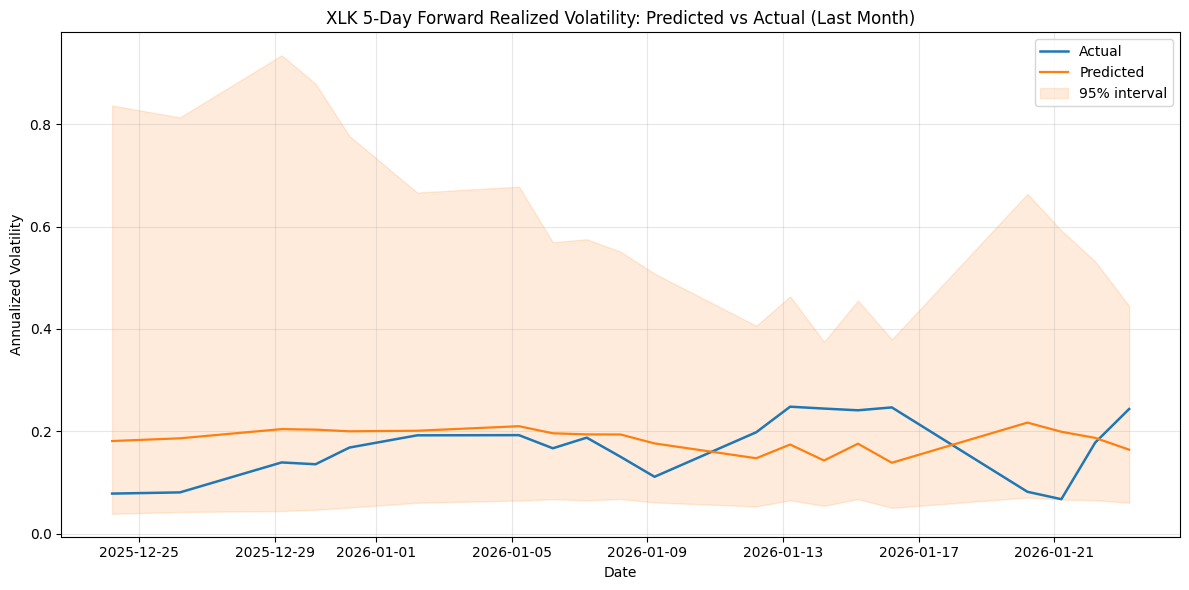

In [5]:
# Predict over the most recent month
window_offset = parse_window(plot_window)
last_date = dataset.index.max()
start_window = last_date - window_offset
plot_df = dataset.loc[(dataset.index > start_window) & (dataset.index <= last_date)]
if plot_df.empty:
    raise ValueError("No data available in the requested window.")

model.eval()
likelihood.eval()

plot_x_df = apply_scaler(plot_df, feature_cols, scaler)
plot_x = torch.tensor(plot_x_df.values, dtype=torch.float32)
plot_noise = torch.tensor(plot_df["noise"].values, dtype=torch.float32).clamp_min(1e-8)

with torch.no_grad():
    preds = likelihood(model(plot_x), noise=plot_noise)
    mean = preds.mean.detach().cpu().numpy()
    std = preds.variance.sqrt().detach().cpu().numpy()

actual_log = plot_df["target"].to_numpy()
pred_vol = np.exp(mean)
actual_vol = np.exp(actual_log)
lower_vol = np.exp(mean - 1.96 * std)
upper_vol = np.exp(mean + 1.96 * std)

plt.figure(figsize=(12, 6))
plt.plot(plot_df.index, actual_vol, label="Actual", linewidth=1.8, color="#1f77b4")
plt.plot(plot_df.index, pred_vol, label="Predicted", linewidth=1.6, color="#ff7f0e")
plt.fill_between(plot_df.index, lower_vol, upper_vol, color="#ff7f0e", alpha=0.15, label="95% interval")

plt.title("XLK 5-Day Forward Realized Volatility: Predicted vs Actual (Last Month)")
plt.ylabel("Annualized Volatility")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
